In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, professional aesthetic for our plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (10, 6), 'font.size': 12})

print("Libraries loaded successfully!")


Libraries loaded successfully!


In [11]:
# ==========================================
# 0. Setup and Data Loading
# ==========================================
# Set seaborn aesthetic defaults
sns.set_theme(style="whitegrid", palette="muted")

# Load data
df = pd.read_csv('evaluation_results\\natural_checkpoints_evaluation.csv')

# Identify the best/latest epoch for final evaluations
BEST_EPOCH = df['epoch'].max()

# Create a slice of the dataset for the final epoch to avoid SettingWithCopy warnings
df_final = df[df['epoch'] == BEST_EPOCH].copy()

# Pre-calculate relative confidence drop for later use
df_final['relative_conf_drop_pct'] = (df_final['conf_drop'] / df_final['baseline_conf']) * 100

print(f"Loaded {len(df)} total records.")
print(f"Evaluating final performance on Epoch {BEST_EPOCH} ({len(df_final)} records).")

Loaded 4320 total records.
Evaluating final performance on Epoch 35 (540 records).


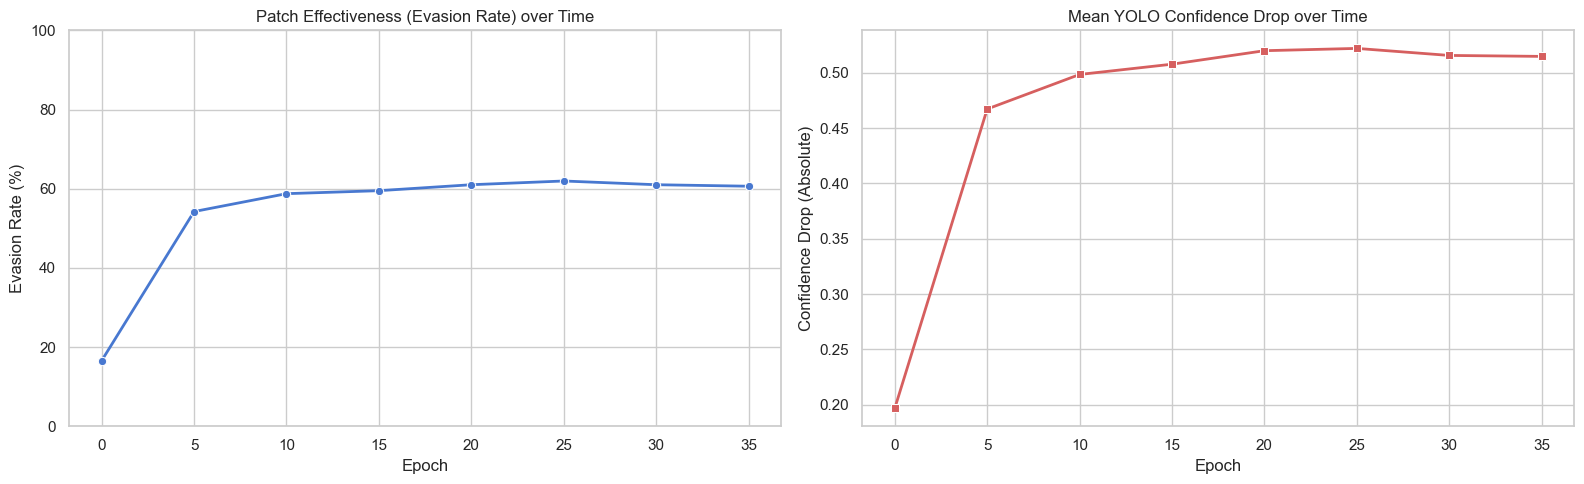

In [12]:
# Aggregate metrics per epoch
epoch_stats = df.groupby('epoch').agg(
    total_baseline_detected=('baseline_detected', 'sum'),
    total_evasions=('evasion_success', 'sum'),
    mean_conf_drop=('conf_drop', 'mean')
).reset_index()

# Calculate evasion rate (as a percentage)
epoch_stats['evasion_rate'] = (epoch_stats['total_evasions'] / epoch_stats['total_baseline_detected']) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Evasion Rate
sns.lineplot(data=epoch_stats, x='epoch', y='evasion_rate', marker='o', ax=axes[0], color='b', linewidth=2)
axes[0].set_title('Patch Effectiveness (Evasion Rate) over Time')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Evasion Rate (%)')
axes[0].set_ylim(0, 100)

# Plot 2: Confidence Drop
sns.lineplot(data=epoch_stats, x='epoch', y='mean_conf_drop', marker='s', ax=axes[1], color='r', linewidth=2)
axes[1].set_title('Mean YOLO Confidence Drop over Time')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Confidence Drop (Absolute)')

plt.tight_layout()
plt.show()

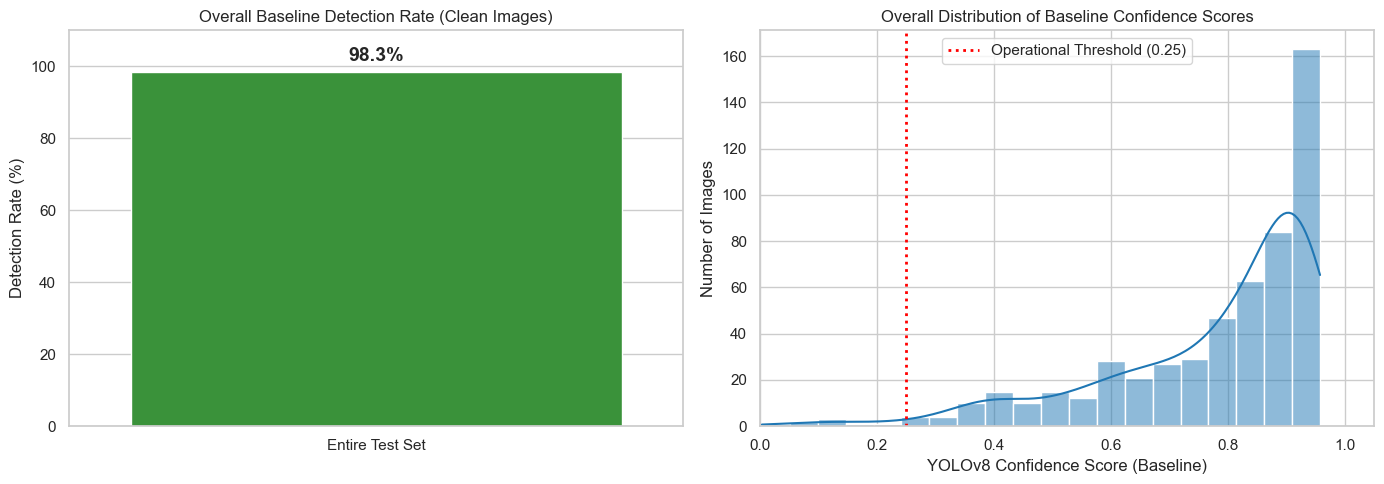

=== Experiment 1: Baseline Detection Summary ===
Total Clean Images Tested: 540
Total Successfully Detected (Baseline > 0.25): 531
Overall Baseline Detection Rate: 98.33%
Overall Mean Baseline Confidence: 0.775


In [27]:
# --- Cell: Experiment 1 - Baseline Detection (Overall Control) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calculate overall statistics
total_images = len(df_final)
total_detected = df_final['baseline_detected'].sum()
overall_rate = (total_detected / total_images) * 100

# Calculate overall average confidence across ALL clean images
overall_mean_conf = df_final['baseline_conf'].mean()

# 1. Overall Baseline Detection Rate (Single Bar)
sns.barplot(x=['Entire Test Set'], y=[overall_rate], color='#2ca02c', ax=axes[0])
axes[0].set_title('Overall Baseline Detection Rate (Clean Images)')
axes[0].set_ylabel('Detection Rate (%)')
axes[0].set_ylim(0, 110)

# Add text annotation for the exact percentage
axes[0].text(0, overall_rate + 2, f"{overall_rate:.1f}%", ha='center', va='bottom', fontweight='bold', fontsize=14)

# 2. Overall Baseline Confidence Distribution (Histogram)
sns.histplot(data=df_final, x='baseline_conf', bins=20, kde=True, color='#1f77b4', ax=axes[1])
axes[1].axvline(x=0.25, color='red', linestyle=':', linewidth=2, label='Operational Threshold (0.25)')

axes[1].set_title('Overall Distribution of Baseline Confidence Scores')
axes[1].set_xlabel('YOLOv8 Confidence Score (Baseline)')
axes[1].set_ylabel('Number of Images')
axes[1].set_xlim(0, 1.05)
axes[1].legend()

plt.tight_layout()
plt.show()

# Print Overall Summary Statistics
print("=== Experiment 1: Baseline Detection Summary ===")
print(f"Total Clean Images Tested: {total_images}")
print(f"Total Successfully Detected (Baseline > 0.25): {total_detected}")
print(f"Overall Baseline Detection Rate: {overall_rate:.2f}%")
print(f"Overall Mean Baseline Confidence: {overall_mean_conf:.3f}")

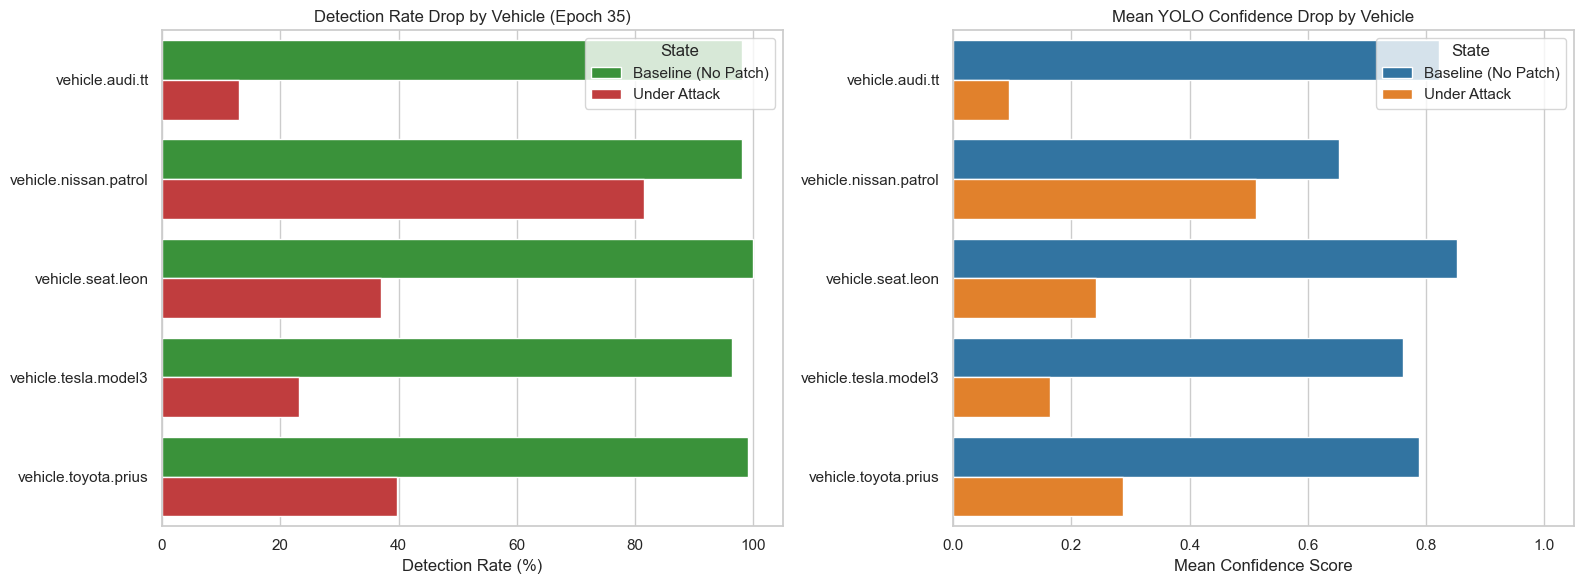

In [28]:
# Calculate detection rates and confidence by vehicle
vehicle_stats = df_final.groupby('vehicle_id').agg(
    total_samples=('filename', 'count'),
    baseline_detected_pct=('baseline_detected', lambda x: x.mean() * 100),
    patched_detected_pct=('patched_detected', lambda x: x.mean() * 100),
    mean_baseline_conf=('baseline_conf', 'mean'),
    mean_patched_conf=('patched_conf', 'mean')
).reset_index()

# 1. Reshape data for side-by-side plotting (Detection Rates)
veh_det_melted = vehicle_stats.melt(id_vars='vehicle_id', 
                                    value_vars=['baseline_detected_pct', 'patched_detected_pct'],
                                    var_name='State', value_name='Detection Rate (%)')
veh_det_melted['State'] = veh_det_melted['State'].replace({
    'baseline_detected_pct': 'Baseline (No Patch)', 
    'patched_detected_pct': 'Under Attack'
})

# 2. Reshape data for side-by-side plotting (Mean Confidence)
veh_conf_melted = vehicle_stats.melt(id_vars='vehicle_id', 
                                     value_vars=['mean_baseline_conf', 'mean_patched_conf'],
                                     var_name='State', value_name='Mean Confidence Score')
veh_conf_melted['State'] = veh_conf_melted['State'].replace({
    'mean_baseline_conf': 'Baseline (No Patch)', 
    'mean_patched_conf': 'Under Attack'
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Side-by-side Detection Rates
sns.barplot(data=veh_det_melted, y='vehicle_id', x='Detection Rate (%)', hue='State', ax=axes[0], palette=['#2ca02c', '#d62728'])
axes[0].set_title(f'Detection Rate Drop by Vehicle (Epoch {BEST_EPOCH})')
axes[0].set_ylabel('')
axes[0].set_xlabel('Detection Rate (%)')
axes[0].set_xlim(0, 105)

# Plot 2: Side-by-side Mean Confidence Scores
sns.barplot(data=veh_conf_melted, y='vehicle_id', x='Mean Confidence Score', hue='State', ax=axes[1], palette=['#1f77b4', '#ff7f0e'])
axes[1].set_title('Mean YOLO Confidence Drop by Vehicle')
axes[1].set_xlabel('Mean Confidence Score')
axes[1].set_ylabel('')
axes[1].set_xlim(0, 1.05)

plt.tight_layout()
plt.show()

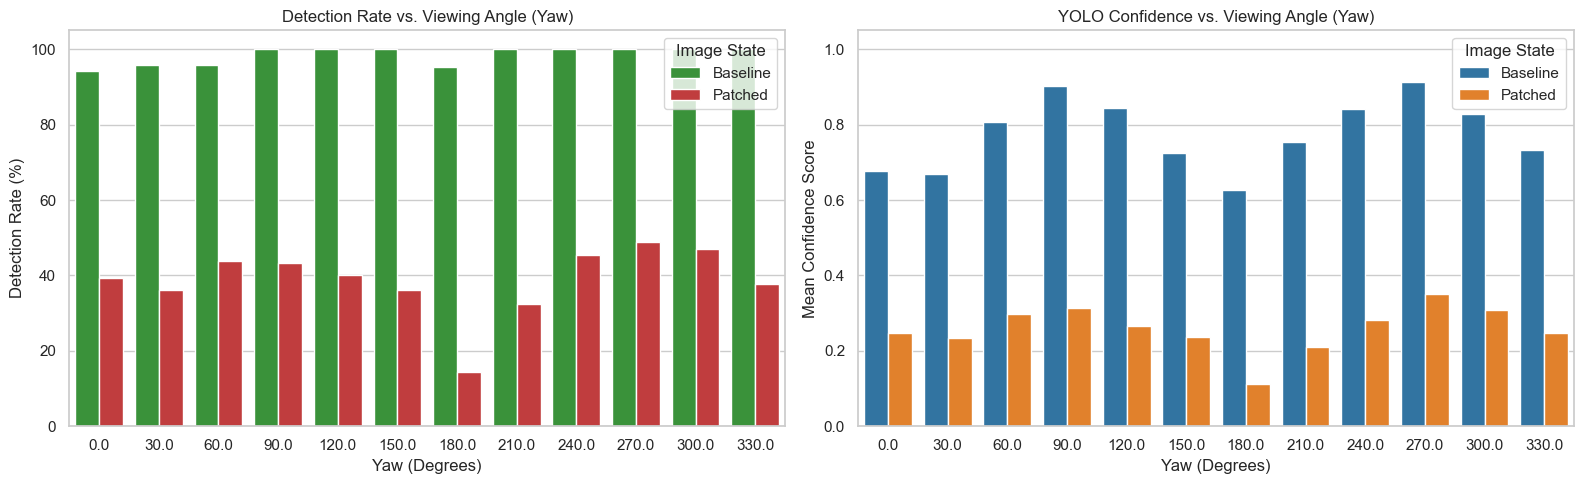

In [14]:
# Calculate metrics by yaw angle
yaw_stats = df_final.groupby('yaw').agg(
    baseline_detected_pct=('baseline_detected', lambda x: x.mean() * 100),
    patched_detected_pct=('patched_detected', lambda x: x.mean() * 100),
    mean_baseline_conf=('baseline_conf', 'mean'),
    mean_patched_conf=('patched_conf', 'mean')
).reset_index()

# 1. Prepare Detection Rate Data
yaw_det_melted = yaw_stats.melt(id_vars='yaw', 
                                value_vars=['baseline_detected_pct', 'patched_detected_pct'],
                                var_name='State', value_name='Detection Rate (%)')
yaw_det_melted['State'] = yaw_det_melted['State'].replace({'baseline_detected_pct': 'Baseline', 'patched_detected_pct': 'Patched'})

# 2. Prepare Confidence Data
yaw_conf_melted = yaw_stats.melt(id_vars='yaw', 
                                 value_vars=['mean_baseline_conf', 'mean_patched_conf'],
                                 var_name='State', value_name='Mean Confidence')
yaw_conf_melted['State'] = yaw_conf_melted['State'].replace({'mean_baseline_conf': 'Baseline', 'mean_patched_conf': 'Patched'})


plt.figure(figsize=(16, 5))

# Plot 1: Detection Rates
plt.subplot(1, 2, 1)
sns.barplot(data=yaw_det_melted, x='yaw', y='Detection Rate (%)', hue='State', palette=['#2ca02c', '#d62728'])
plt.title(f'Detection Rate vs. Viewing Angle (Yaw)')
plt.xlabel('Yaw (Degrees)')
plt.ylabel('Detection Rate (%)')
plt.ylim(0, 105)
plt.legend(title='Image State')

# Plot 2: Confidence Levels
plt.subplot(1, 2, 2)
sns.barplot(data=yaw_conf_melted, x='yaw', y='Mean Confidence', hue='State', palette=['#1f77b4', '#ff7f0e'])
plt.title(f'YOLO Confidence vs. Viewing Angle (Yaw)')
plt.xlabel('Yaw (Degrees)')
plt.ylabel('Mean Confidence Score')
plt.ylim(0, 1.05)
plt.legend(title='Image State')

plt.tight_layout()
plt.show()

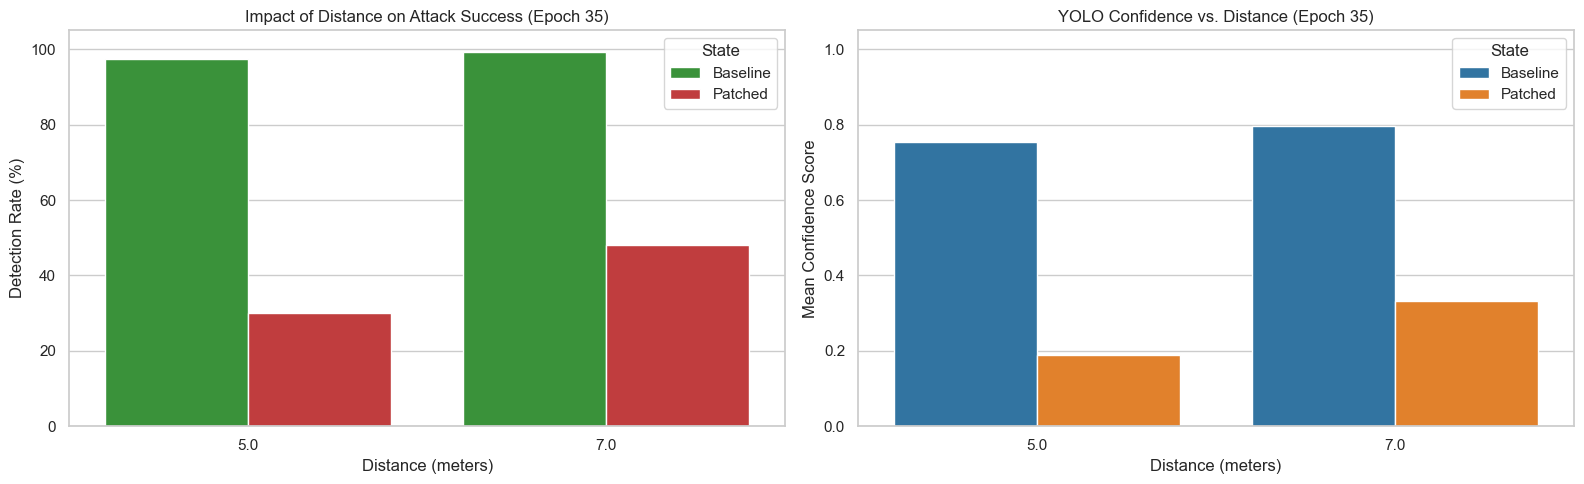

In [29]:
# --- Cell 4: Metrics by Distance ---
# Calculate detection rates and confidence by distance
dist_stats = df_final.groupby('distance').agg(
    baseline_detected_pct=('baseline_detected', lambda x: x.mean() * 100),
    patched_detected_pct=('patched_detected', lambda x: x.mean() * 100),
    mean_baseline_conf=('baseline_conf', 'mean'),
    mean_patched_conf=('patched_conf', 'mean')
).reset_index()

# 1. Reshape data for side-by-side plotting (Detection Rates)
dist_det_melted = dist_stats.melt(id_vars='distance', 
                                  value_vars=['baseline_detected_pct', 'patched_detected_pct'],
                                  var_name='State', value_name='Detection Rate (%)')
dist_det_melted['State'] = dist_det_melted['State'].replace({
    'baseline_detected_pct': 'Baseline', 
    'patched_detected_pct': 'Patched'
})

# 2. Reshape data for side-by-side plotting (Mean Confidence)
dist_conf_melted = dist_stats.melt(id_vars='distance', 
                                   value_vars=['mean_baseline_conf', 'mean_patched_conf'],
                                   var_name='State', value_name='Mean Confidence Score')
dist_conf_melted['State'] = dist_conf_melted['State'].replace({
    'mean_baseline_conf': 'Baseline', 
    'mean_patched_conf': 'Patched'
})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Side-by-side Detection Rates
sns.barplot(data=dist_det_melted, x='distance', y='Detection Rate (%)', hue='State', ax=axes[0], palette=['#2ca02c', '#d62728'])
axes[0].set_title(f'Impact of Distance on Attack Success (Epoch {BEST_EPOCH})')
axes[0].set_xlabel('Distance (meters)')
axes[0].set_ylabel('Detection Rate (%)')
axes[0].set_ylim(0, 105)

# Plot 2: Side-by-side Mean Confidence Scores
sns.barplot(data=dist_conf_melted, x='distance', y='Mean Confidence Score', hue='State', ax=axes[1], palette=['#1f77b4', '#ff7f0e'])
axes[1].set_title(f'YOLO Confidence vs. Distance (Epoch {BEST_EPOCH})')
axes[1].set_xlabel('Distance (meters)')
axes[1].set_ylabel('Mean Confidence Score')
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

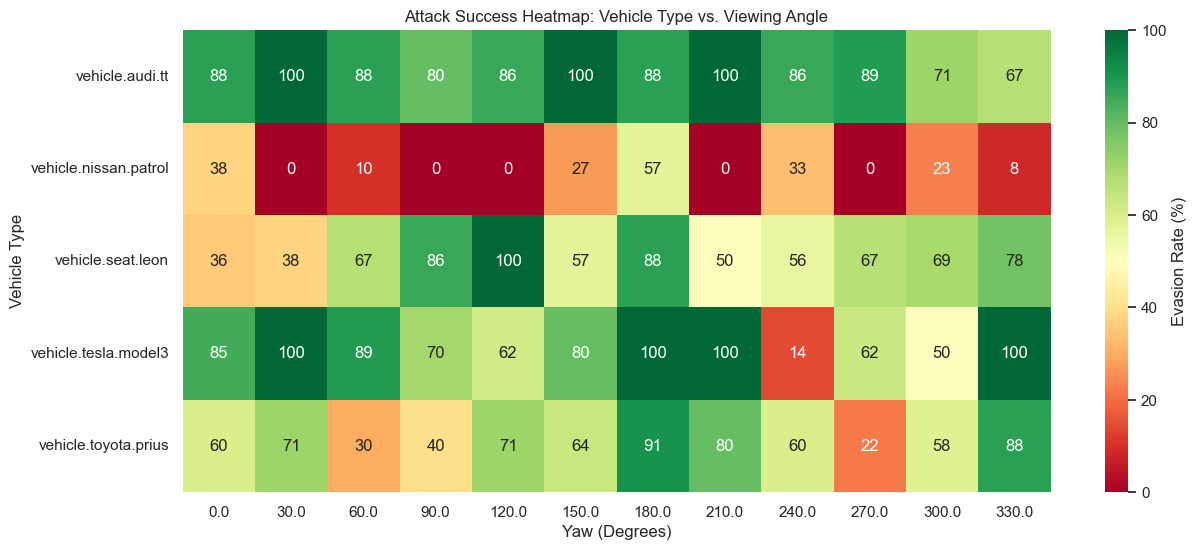

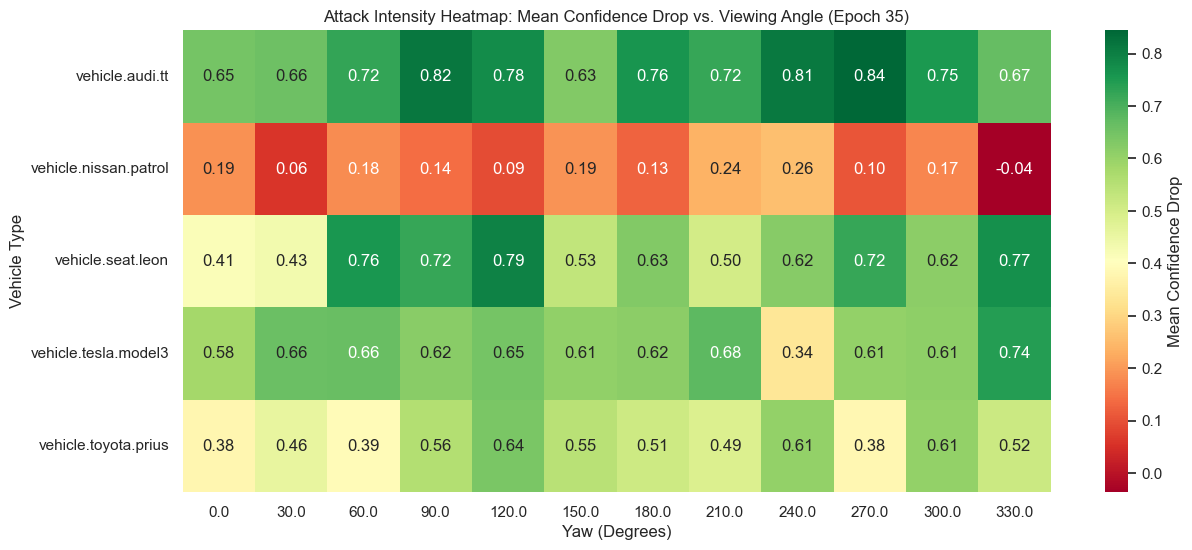

In [16]:
# Create a pivot table: Rows = Vehicles, Cols = Yaw, Values = Evasion Rate
heatmap_data = df_final[df_final['baseline_detected'] == 1].pivot_table(
    index='vehicle_id', 
    columns='yaw', 
    values='evasion_success', 
    aggfunc=lambda x: x.mean() * 100
)

plt.figure(figsize=(14, 6))
# Using a Red-Yellow-Green colormap (Green = High Evasion/Success, Red = Low Evasion/Failure)
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="RdYlGn", cbar_kws={'label': 'Evasion Rate (%)'})
plt.title('Attack Success Heatmap: Vehicle Type vs. Viewing Angle')
plt.xlabel('Yaw (Degrees)')
plt.ylabel('Vehicle Type')
plt.yticks(rotation=0)
plt.show()


# Create pivot table: Rows = Vehicles, Cols = Yaw, Values = Mean Confidence Drop
heatmap_conf_data = df_final[df_final['baseline_detected'] == 1].pivot_table(
    index='vehicle_id', 
    columns='yaw', 
    values='conf_drop', 
    aggfunc='mean'
)

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_conf_data, annot=True, fmt=".2f", cmap="RdYlGn", cbar_kws={'label': 'Mean Confidence Drop'})
plt.title(f'Attack Intensity Heatmap: Mean Confidence Drop vs. Viewing Angle (Epoch {BEST_EPOCH})')
plt.xlabel('Yaw (Degrees)')
plt.ylabel('Vehicle Type')
plt.yticks(rotation=0)
plt.show()



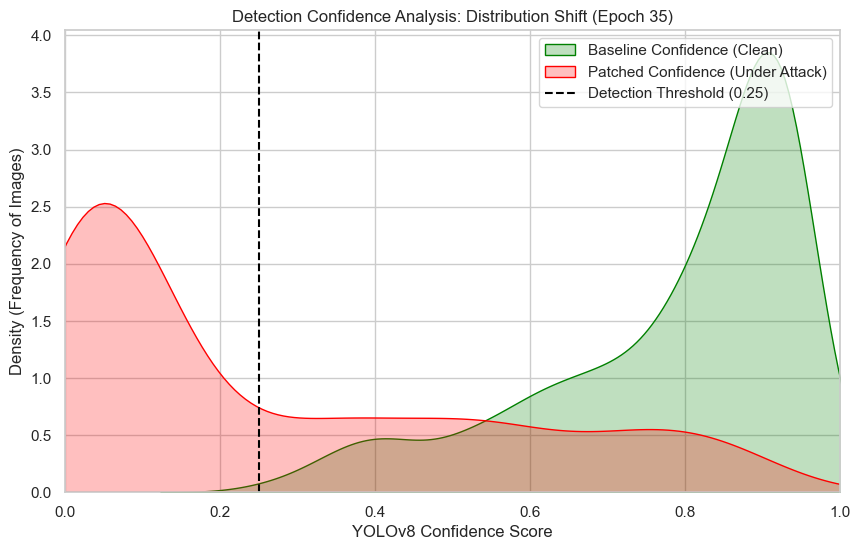

In [17]:
# --- Cell 8: Confidence Score Distribution Shift ---
plt.figure(figsize=(10, 6))

# Plot the distribution of Baseline vs Patched confidence scores for the best epoch
sns.kdeplot(data=df_final[df_final['baseline_detected'] == 1], x='baseline_conf', 
            fill=True, color='green', label='Baseline Confidence (Clean)')
sns.kdeplot(data=df_final[df_final['baseline_detected'] == 1], x='patched_conf', 
            fill=True, color='red', label='Patched Confidence (Under Attack)')

# Add a vertical line for your standard operational threshold
plt.axvline(x=0.25, color='black', linestyle='--', label='Detection Threshold (0.25)')

plt.title(f'Detection Confidence Analysis: Distribution Shift (Epoch {BEST_EPOCH})')
plt.xlabel('YOLOv8 Confidence Score')
plt.ylabel('Density (Frequency of Images)')
plt.xlim(0, 1.0)
plt.legend()
plt.show()


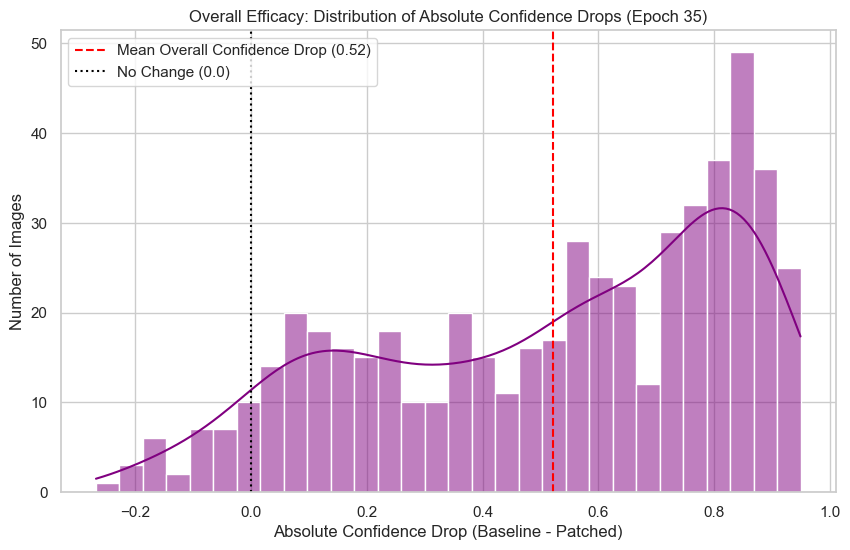

Total Valid Targets: 531
Across all targets, the patch reduced confidence by an average of 0.52


In [19]:
# --- Cell: Overall Confidence Drop Distribution ---
# Filter for ALL images where the vehicle was originally detected
valid_attacks = df_final[df_final['baseline_detected'] == 1]

plt.figure(figsize=(10, 6))

# Plot the distribution of ALL confidence drops
sns.histplot(valid_attacks['conf_drop'], bins=30, kde=True, color='purple')

# Calculate the overall mean drop
mean_drop = valid_attacks['conf_drop'].mean()
plt.axvline(x=mean_drop, color='red', linestyle='--', 
            label=f'Mean Overall Confidence Drop ({mean_drop:.2f})')

# Add a reference line for 0 (no drop)
plt.axvline(x=0, color='black', linestyle=':', label='No Change (0.0)')

plt.title(f'Overall Efficacy: Distribution of Absolute Confidence Drops (Epoch {BEST_EPOCH})')
plt.xlabel('Absolute Confidence Drop (Baseline - Patched)')
plt.ylabel('Number of Images')
plt.legend()
plt.show()

print(f"Total Valid Targets: {len(valid_attacks)}")
print(f"Across all targets, the patch reduced confidence by an average of {mean_drop:.2f}")

Total Patch Backfires (Confidence Increased): 31 out of 531 images


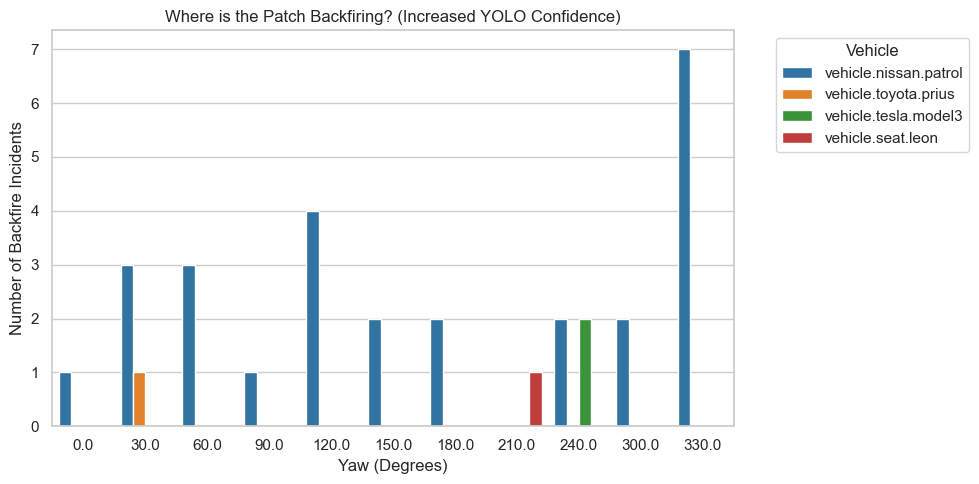

In [21]:
# Filter for instances where the patch INCREASED model confidence
backfires = df_final[(df_final['baseline_detected'] == 1) & (df_final['conf_drop'] < 0)]

print(f"Total Patch Backfires (Confidence Increased): {len(backfires)} out of {len(valid_data)} images")

if len(backfires) > 0:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=backfires, x='yaw', hue='vehicle_id', palette='tab10')
    plt.title('Where is the Patch Backfiring? (Increased YOLO Confidence)')
    plt.xlabel('Yaw (Degrees)')
    plt.ylabel('Number of Backfire Incidents')
    plt.legend(title='Vehicle', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()